[*********************100%***********************]  1 of 1 completed


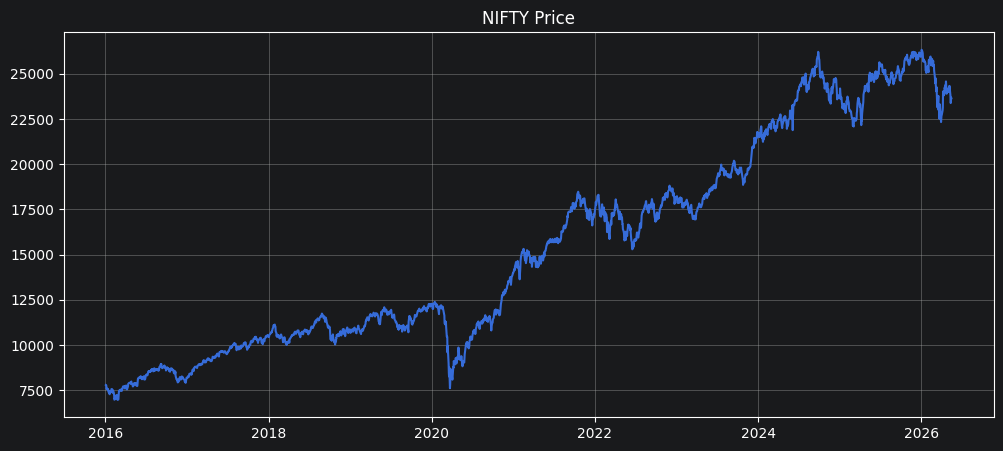

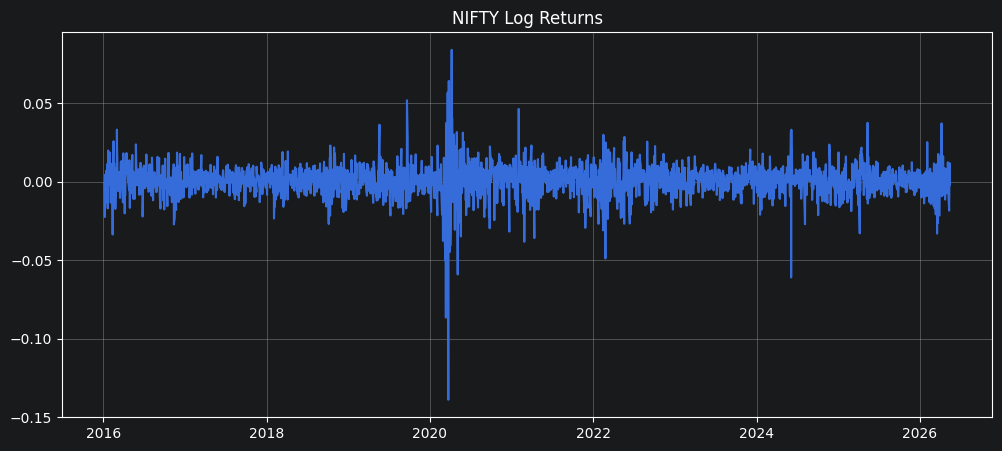

In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Download NIFTY data
df = yf.download("^NSEI", start="2016-01-01")

# Simple returns
df["simple_return"] = df["Close"].pct_change()

# Log returns
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))

# PRICE CHART
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Close"])
plt.title("NIFTY Price")
plt.grid(True)
plt.show()

# RETURN CHART
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["log_return"])
plt.title("NIFTY Log Returns")
plt.grid(True)
plt.show()

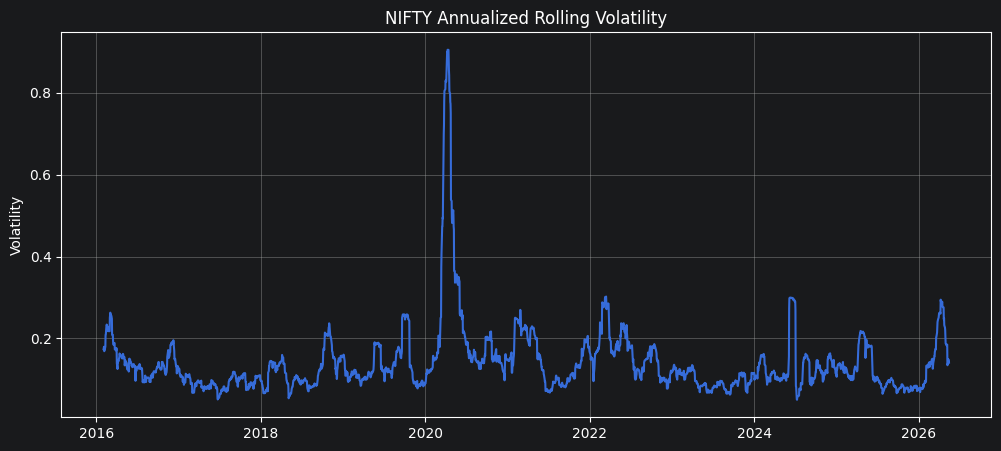

In [10]:
# Rolling 20-day volatility
df["rolling_vol"] = df["log_return"].rolling(20).std()

# Annualized volatility
df["annualized_vol"] = df["rolling_vol"] * np.sqrt(252)

# Plot annualized volatility
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["annualized_vol"])
plt.title("NIFTY Annualized Rolling Volatility")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()


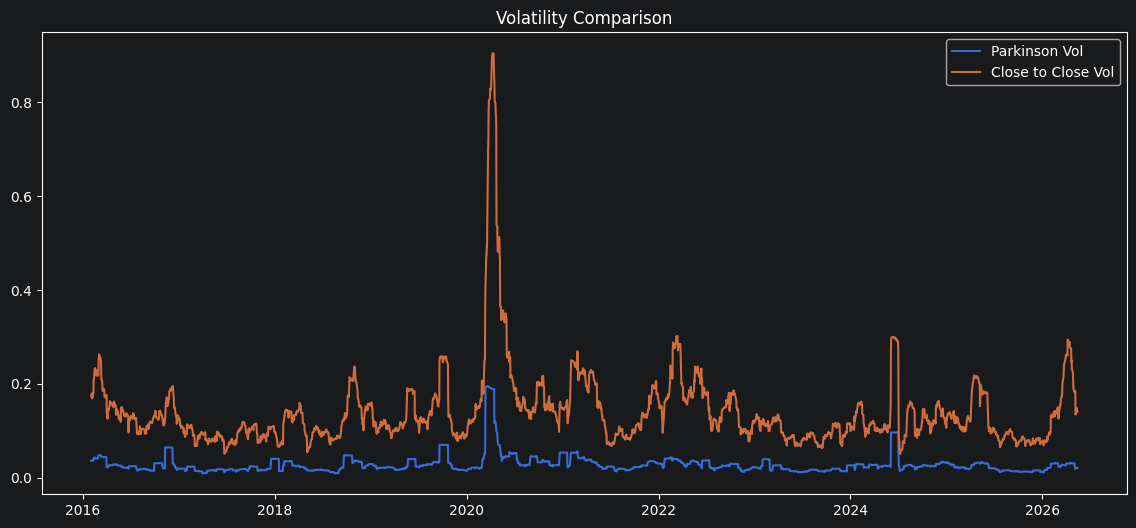

In [11]:
df['close_vol'] = (df['log_return'].rolling(20).std() * np.sqrt(252))
parkinson = (1 / (4 * np.log(2))) * (np.log(df['High'] / df['Low'])) ** 2
df['parkinson_vol'] = np.sqrt(parkinson.rolling(20).std() * np.sqrt(252))

plt.figure(figsize=(14, 6))

plt.plot(df.index, df["parkinson_vol"], label="Parkinson Vol")
plt.plot(df.index, df["close_vol"], label="Close to Close Vol")

plt.title("Volatility Comparison")
plt.legend()
plt.show()

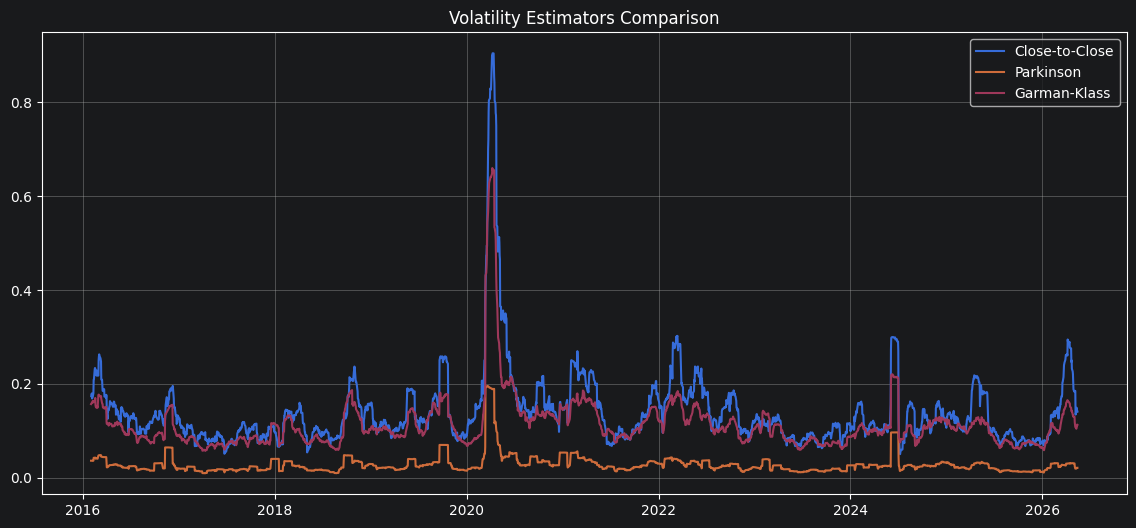

In [12]:
# Garman-Klass estimator
gk = (0.5 * (np.log(df["High"] / df["Low"])) ** 2- (2 * np.log(2) - 1) *
(np.log(df["Close"] / df["Open"])) ** 2)

df["gk_vol"] = (np.sqrt(gk.rolling(20).mean()) * np.sqrt(252))

# Plot comparison
plt.figure(figsize=(14, 6))

plt.plot(df.index, df["close_vol"], label="Close-to-Close")
plt.plot(df.index, df["parkinson_vol"], label="Parkinson")
plt.plot(df.index, df["gk_vol"], label="Garman-Klass")

plt.title("Volatility Estimators Comparison")
plt.legend()
plt.grid(True)

plt.show()


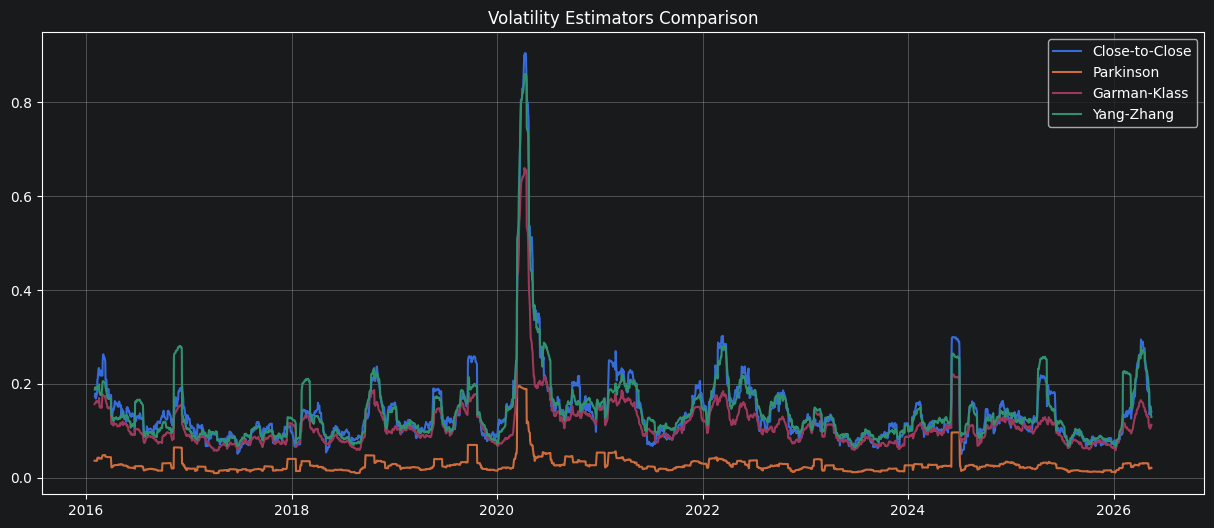

In [13]:
# Yang-Zhang Estimator
# -----------------------------

# Overnight returns
overnight = np.log(df["Open"] / df["Close"].shift(1))

# Open-to-close returns
open_close = np.log(df["Close"] / df["Open"])

# Rogers-Satchell component
rs = (
        np.log(df["High"] / df["Close"]) *
        np.log(df["High"] / df["Open"]) +
        np.log(df["Low"] / df["Close"]) *
        np.log(df["Low"] / df["Open"])
)

window = 20

sigma_o = overnight.rolling(window).var()
sigma_c = open_close.rolling(window).var()
sigma_rs = rs.rolling(window).mean()

k = 0.34 / (1.34 + (window + 1) / (window - 1))

yz = sigma_o + k * sigma_c + (1 - k) * sigma_rs

df["yz_vol"] = np.sqrt(yz) * np.sqrt(252)

# Plot comparison
plt.figure(figsize=(15, 6))

plt.plot(df.index, df["close_vol"], label="Close-to-Close")
plt.plot(df.index, df["parkinson_vol"], label="Parkinson")
plt.plot(df.index, df["gk_vol"], label="Garman-Klass")
plt.plot(df.index, df["yz_vol"], label="Yang-Zhang")

plt.title("Volatility Estimators Comparison")
plt.legend()
plt.grid(True)

plt.show()
